# 06 — Taxa de mortalidade evitável padronizada por idade

**Pré-requisito:** `02_transformacao.ipynb` executado — a `feature_matrix.parquet` já traz **`TAXA_EVITAVEL_100K`** (bruta) e **`TAXA_PADRONIZADA_100K`** (padronizada por idade) lado a lado. A extração da população por faixa etária (Censo 2022) está no notebook 01 e o cálculo da padronização no notebook 02.

## O problema da taxa bruta

A taxa bruta não corrige a **estrutura etária** do município. Como as causas evitáveis na faixa 5–74 anos são dominadas por doenças crônicas (que matam mais perto dos 70), municípios com população mais envelhecida têm taxa bruta maior **só por isso**. O efeito é um paradoxo: pela taxa bruta, Sul e Sudeste (ricos, mais envelhecidos) aparecem com mortalidade *maior* que Norte e Nordeste (pobres, mais jovens) — o oposto do que a tese socioeconômica prevê.

## A padronização (relembrando a fórmula do nb02)

A padronização direta calcula a taxa que cada município teria **se tivesse a estrutura etária padrão do Brasil**:

$$\text{taxa pad.}_m = \sum_{a} \frac{\text{óbitos}_{m,a}}{\text{população}_{m,a}} \times w_a \times 100{.}000,\qquad w_a = \frac{\text{pop. nacional da faixa } a}{\text{pop. nacional 5--74}}$$

## Objetivo deste notebook

Avaliar o efeito da padronização: (1) comparar o gradiente regional bruto vs padronizado; (2) medir o impacto nos coeficientes da regressão; (3) persistir a comparação município a município.

## Saída
```
data/processed/taxa_padronizada.parquet   # CODMUN6 -> taxa bruta e padronizada
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT          = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 180)
print("Imports OK")

Imports OK


## 1. Carregar e agregar por município

Lemos a feature matrix (painel município × ano) e agregamos para o nível de município (média das taxas dos 3 anos), que é o nível desta análise comparativa.

In [2]:
fm = pd.read_parquet(PROCESSED_DIR / "feature_matrix.parquet")
fm["CODMUN6"] = fm["CODMUN6"].astype(str).str.zfill(6)

feat = ["IDHM", "GINI", "LOG_PIB_PER_CAPITA", "LOG_DESPESA_SAUDE_PC",
        "PMPOB", "ESPVIDA", "T_ANALF15M", "T_AGUA"]

comp = (fm.groupby("CODMUN6")
          .agg(MUNICIPIO_NOME=("MUNICIPIO_NOME", "first"),
               UF=("UF", "first"), REGIAO=("REGIAO", "first"),
               TAXA_BRUTA_100K=("TAXA_EVITAVEL_100K", "mean"),
               TAXA_PADRONIZADA_100K=("TAXA_PADRONIZADA_100K", "mean"),
               **{f: (f, "mean") for f in feat})
          .reset_index())

cob = comp["TAXA_PADRONIZADA_100K"].notna().mean() * 100
print(f"Municípios: {len(comp):,} | cobertura da taxa padronizada: {cob:.1f}%")
comp[["TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"]].describe().round(1)

Municípios: 5,571 | cobertura da taxa padronizada: 100.0%


,TAXA_BRUTA_100K,TAXA_PADRONIZADA_100K
count,5570.0,5570.0
mean,225.9,244.5
std,64.1,56.6
min,41.2,64.3
25%,182.4,207.7
50%,221.9,242.9
75%,264.2,280.1
max,685.9,623.1


## 2. Comparação do gradiente regional

A pergunta central: a padronização corrige o paradoxo (Sul/Sudeste acima de Norte/Nordeste)?

In [3]:
tab = (comp.groupby("REGIAO")
           .agg(n=("CODMUN6", "size"),
                taxa_bruta=("TAXA_BRUTA_100K", "mean"),
                taxa_padronizada=("TAXA_PADRONIZADA_100K", "mean"))
           .round(1)
           .reindex(["N", "NE", "CO", "SE", "S"]))
print("Taxa média por região (média dos municípios):")
print(tab)
print(f"\nCorrelação bruta × padronizada: {comp['TAXA_BRUTA_100K'].corr(comp['TAXA_PADRONIZADA_100K']):.3f}")

Taxa média por região (média dos municípios):
           n  taxa_bruta  taxa_padronizada
REGIAO                                    
N        450       158.9             227.7
NE      1794       204.1             247.4
CO       468       229.8             257.3
SE      1668       244.6             244.5
S       1191       256.5             241.8

Correlação bruta × padronizada: 0.743


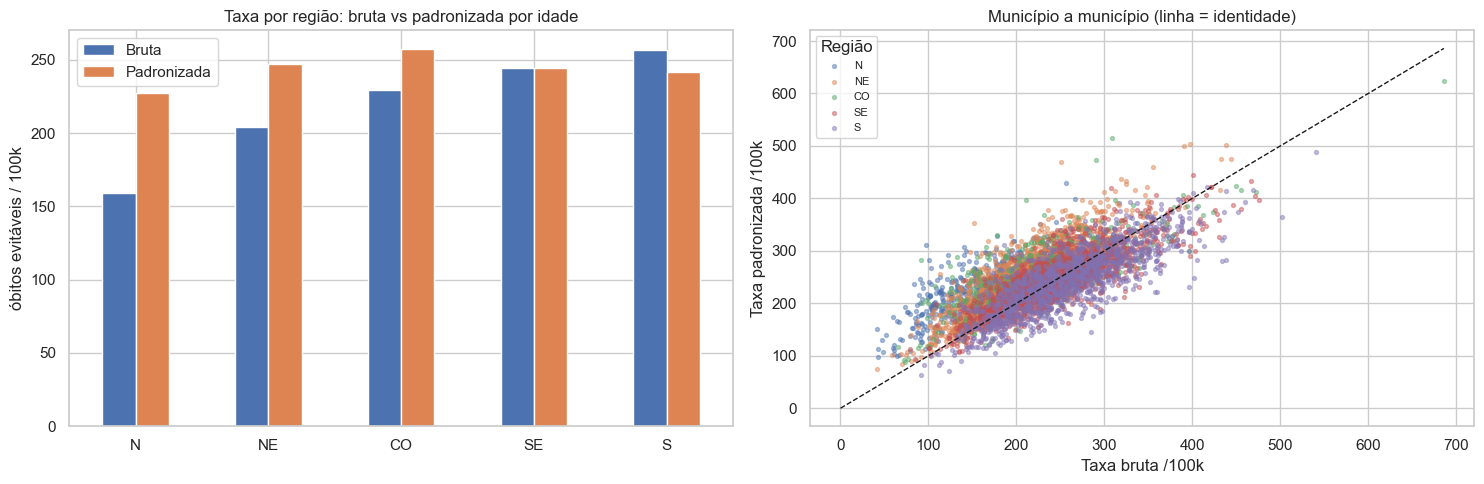

In [4]:
ordem = ["N", "NE", "CO", "SE", "S"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tab[["taxa_bruta", "taxa_padronizada"]].plot(kind="bar", ax=axes[0], edgecolor="white")
axes[0].set_title("Taxa por região: bruta vs padronizada por idade")
axes[0].set_ylabel("óbitos evitáveis / 100k"); axes[0].set_xlabel("")
axes[0].legend(["Bruta", "Padronizada"]); plt.setp(axes[0].get_xticklabels(), rotation=0)

for reg in ordem:
    s = comp[comp["REGIAO"] == reg]
    axes[1].scatter(s["TAXA_BRUTA_100K"], s["TAXA_PADRONIZADA_100K"], s=8, alpha=0.45, label=reg)
lim = [0, comp[["TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"]].max().max()]
axes[1].plot(lim, lim, "k--", linewidth=1)
axes[1].set_xlabel("Taxa bruta /100k"); axes[1].set_ylabel("Taxa padronizada /100k")
axes[1].set_title("Município a município (linha = identidade)")
axes[1].legend(title="Região", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Impacto na regressão

Reestimamos um OLS transversal (1 linha por município) com as mesmas features socioeconômicas, comparando os coeficientes quando o alvo é a taxa **bruta** vs a **padronizada**. Esperamos que o sinal do IDH-M deixe de ser positivo (paradoxo) e passe a refletir a relação esperada (mais desenvolvimento → menos mortalidade).

In [5]:
d = comp.dropna(subset=feat + ["TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"]).copy()
X = sm.add_constant(d[feat])

linhas, modelos = [], {}
for alvo in ("TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"):
    r = sm.OLS(d[alvo], X).fit(cov_type="HC3")
    modelos[alvo] = r
    for f in feat:
        linhas.append({"feature": f, "alvo": alvo,
                       "coef": round(r.params[f], 2), "p": round(r.pvalues[f], 4)})

comp_coef = pd.DataFrame(linhas).pivot(index="feature", columns="alvo", values=["coef", "p"])
print(f"R²  bruta={modelos['TAXA_BRUTA_100K'].rsquared:.3f} | "
      f"padronizada={modelos['TAXA_PADRONIZADA_100K'].rsquared:.3f}\n")
comp_coef

R²  bruta=0.232 | padronizada=0.078



coef                                     p                      
alvo                 TAXA_BRUTA_100K TAXA_PADRONIZADA_100K TAXA_BRUTA_100K TAXA_PADRONIZADA_100K
feature                                                                                         
ESPVIDA                        -0.08                 -3.56          0.8880                0.0000
GINI                           43.64                 83.50          0.0109                0.0000
IDHM                          -77.13               -124.85          0.0227                0.0001
LOG_DESPESA_SAUDE_PC           24.03                -12.10          0.0000                0.0000
LOG_PIB_PER_CAPITA            -21.69                  2.91          0.0000                0.0855
PMPOB                          -2.68                 -1.39          0.0000                0.0000
T_AGUA                          0.74                  0.96          0.0000                0.0000
T_ANALF15M                      1.84                  1.48          0.0000                0.0000

## 4. Persistência

Salva a comparação município a município. Também listamos os municípios cuja taxa mais sobe/desce ao padronizar (os mais 'jovens' / 'envelhecidos').

In [6]:
out = PROCESSED_DIR / "taxa_padronizada.parquet"
saida = comp[["CODMUN6", "MUNICIPIO_NOME", "UF", "REGIAO",
              "TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"]].copy()
saida.to_parquet(out, index=False)
print(f"Salvo: {out.name} ({out.stat().st_size/1e3:.1f} KB) | {len(saida):,} municípios")

saida["delta"] = saida["TAXA_PADRONIZADA_100K"] - saida["TAXA_BRUTA_100K"]
cols = ["MUNICIPIO_NOME", "UF", "REGIAO", "TAXA_BRUTA_100K", "TAXA_PADRONIZADA_100K"]
print("\n— Maiores ALTAS ao padronizar (municípios 'jovens', mortalidade subestimada na bruta) —")
display(saida.nlargest(5, "delta")[cols].round(1))
print("— Maiores QUEDAS ao padronizar (municípios 'envelhecidos') —")
display(saida.nsmallest(5, "delta")[cols].round(1))

Salvo: taxa_padronizada.parquet (210.2 KB) | 5,571 municípios

— Maiores ALTAS ao padronizar (municípios 'jovens', mortalidade subestimada na bruta) —


,MUNICIPIO_NOME,UF,REGIAO,TAXA_BRUTA_100K,TAXA_PADRONIZADA_100K
1251,Amparo - PB,PB,NE,251.0,469.2
150,Uiramutã - RR,RR,N,97.1,311.1
5127,Coronel Sapucaia - MS,MS,CO,309.2,515.4
1403,Riacho de Santo Antônio - PB,PB,NE,152.0,353.4
5305,Sapezal - MT,MT,CO,92.0,282.0


— Maiores QUEDAS ao padronizar (municípios 'envelhecidos') —


,MUNICIPIO_NOME,UF,REGIAO,TAXA_BRUTA_100K,TAXA_PADRONIZADA_100K
4774,Floriano Peixoto - RS,RS,S,396.3,231.4
4610,Alecrim - RS,RS,S,438.7,283.1
4777,Forquetinha - RS,RS,S,401.5,248.6
4932,Porto Lucena - RS,RS,S,433.6,281.2
5077,União da Serra - RS,RS,S,284.5,144.8


---

## Conclusão

A padronização por idade **corrige o paradoxo** das taxas brutas:

- **Gradiente regional:** pela taxa bruta, Sul/Sudeste apareciam no topo (artefato de população mais velha). Padronizada, o **Nordeste passa a igualar ou superar** Sudeste e Sul, e o Norte sobe fortemente — coerente com a tese de que regiões menos desenvolvidas têm maior mortalidade evitável quando se neutraliza a estrutura etária.
- **Regressão:** com o alvo padronizado, o coeficiente do **IDH-M torna-se negativo e significativo** (mais desenvolvimento → menos mortalidade) e o **Gini permanece positivo** (mais desigualdade → mais mortalidade). Os sinais passam a refletir a hipótese do projeto.
- O $R^2$ cai porque a taxa padronizada remove a variância de estrutura etária que estava correlacionada com região/desenvolvimento; o que resta é o sinal socioeconômico 'puro', menor mas no sentido correto.

Por isso a `TAXA_PADRONIZADA_100K` é adotada como alvo principal no notebook 03 (regressão) e reportada no 04 (clusterização).

**Limitações remanescentes:** (i) denominador do Censo 2022 usado para os três anos (a estrutura etária muda pouco no período); (ii) a padronização direta é sensível a ruído em municípios pequenos com poucas mortes por faixa — para esses, uma padronização indireta (SMR) seria mais estável; (iii) o padrão usado é a estrutura nacional de 2022 (padrão interno), adequado para comparação entre municípios brasileiros.